In [1]:
import pandas as pd

from sklearn import preprocessing

df = pd.read_csv('cars.csv')

df.head()

,Brand,Body,Mileage,EngineV,Engine Type,Registration,Year,Model,Price
0,Mercedes-Benz,sedan,68,6.0,Petrol,yes,2011,S 600,300000.0
1,Mercedes-Benz,other,37,5.0,Petrol,yes,2012,G 500,300000.0
2,Mercedes-Benz,sedan,29,6.0,Petrol,yes,2011,S-Guard,295000.0
3,Mercedes-Benz,sedan,29,6.0,Petrol,yes,2011,S 600,295000.0
4,Mercedes-Benz,other,6,5.5,Petrol,yes,2016,S 63 AMG,250000.0


In [2]:
le_brand = preprocessing.LabelEncoder()
le_brand.fit(df['Brand']) 

le_body = preprocessing.LabelEncoder()
le_body.fit(df['Body']) 

le_model = preprocessing.LabelEncoder()
le_model.fit(df['Model']) 

le_enginetype = preprocessing.LabelEncoder()
le_enginetype.fit(df['Engine Type']) 

le_reg = preprocessing.LabelEncoder()
le_reg.fit(df['Registration']) 


df['Brand_num'] = le_brand.transform(df['Brand']) 
df['Body_num'] = le_body.transform(df['Body']) 
df['Model_num'] = le_model.transform(df['Model']) 
df['EngineType_num'] = le_enginetype.transform(df['Engine Type']) 
df['Registration_num'] = le_reg.transform(df['Registration']) 

df=df.drop(columns=['Brand','Body','Engine Type','Registration','Model'])
df.head()

,Mileage,EngineV,Year,Price,Brand_num,Body_num,Model_num,EngineType_num,Registration_num
0,68,6.0,2011,300000.0,2,3,239,3,1
1,37,5.0,2012,300000.0,2,2,127,3,1
2,29,6.0,2011,295000.0,2,3,242,3,1
3,29,6.0,2011,295000.0,2,3,239,3,1
4,6,5.5,2016,250000.0,2,2,240,3,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4173 entries, 0 to 4172
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Mileage           4173 non-null   int64  
 1   EngineV           4025 non-null   float64
 2   Year              4173 non-null   int64  
 3   Price             4173 non-null   float64
 4   Brand_num         4173 non-null   int64  
 5   Body_num          4173 non-null   int64  
 6   Model_num         4173 non-null   int64  
 7   EngineType_num    4173 non-null   int64  
 8   Registration_num  4173 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 293.5 KB


In [4]:
df['EngineV'].fillna(value=df['EngineV'].mean(), inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4173 entries, 0 to 4172
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Mileage           4173 non-null   int64  
 1   EngineV           4025 non-null   float64
 2   Year              4173 non-null   int64  
 3   Price             4173 non-null   float64
 4   Brand_num         4173 non-null   int64  
 5   Body_num          4173 non-null   int64  
 6   Model_num         4173 non-null   int64  
 7   EngineType_num    4173 non-null   int64  
 8   Registration_num  4173 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 293.5 KB


C:\Users\aziz1\AppData\Local\Temp\ipykernel_4484\4280477547.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['EngineV'].fillna(value=df['EngineV'].mean(), inplace=True)


In [5]:
df.describe()

,Mileage,EngineV,Year,Price,Brand_num,Body_num,Model_num,EngineType_num,Registration_num
count,4173.000000,4025.000000,4173.000000,4173.000000,4173.000000,4173.000000,4173.000000,4173.000000,4173.000000
mean,164.141625,2.762127,2006.365684,19218.579430,3.171340,2.562425,163.211598,1.301941,0.905584
std,104.763054,4.935196,6.685332,24625.021129,2.084648,1.642627,86.903844,1.359738,0.292442
min,0.000000,0.600000,1969.000000,600.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,90.000000,1.800000,2003.000000,6999.000000,1.000000,1.000000,98.000000,0.000000,1.000000
50%,158.000000,2.200000,2007.000000,11500.000000,3.000000,3.000000,162.000000,1.000000,1.000000
75%,230.000000,3.000000,2012.000000,21700.000000,5.000000,3.000000,226.000000,3.000000,1.000000
max,980.000000,99.990000,2016.000000,300000.000000,6.000000,5.000000,305.000000,3.000000,1.000000


In [6]:
df.columns

Index(['Mileage', 'EngineV', 'Year', 'Price', 'Brand_num', 'Body_num',
       'Model_num', 'EngineType_num', 'Registration_num'],
      dtype='str')

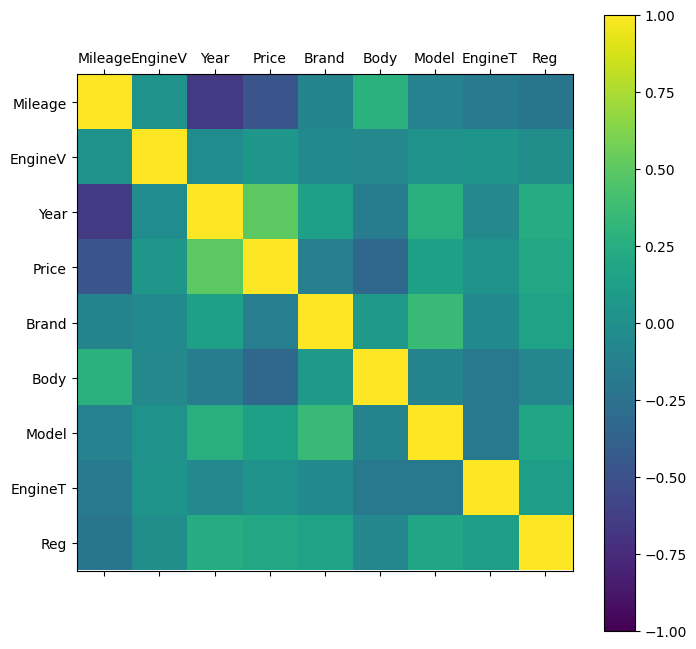

In [7]:
import matplotlib.pyplot as plt

correlations = df.corr(method='pearson')
 
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(1,1,1)

cax = ax.matshow(correlations, vmin=-1, vmax=1)

fig.colorbar(cax)

ticks = [0,1,2,3,4,5,6,7,8]

ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xticklabels(["Mileage","EngineV","Year","Price","Brand","Body","Model","EngineT","Reg"])
ax.set_yticklabels(["Mileage","EngineV","Year","Price","Brand","Body","Model","EngineT","Reg"])

plt.show()

In [8]:
X = df[['Year','Mileage' ,'Body_num','Brand_num']]

y = df['Price']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train.values, y_train)

print('Intercept:', model.intercept_)
print('Coefficients:', model.coef_)

Intercept: -2680235.689541901
Coefficients: [ 1356.34642998   -42.75766634 -2955.09700713 -2358.14678724]


In [9]:
y_pred = model.predict(X_test.values)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from math import sqrt

print ('MSE :', mean_squared_error (y_pred, y_test))
print ('RMSE :', sqrt(mean_squared_error (y_pred, y_test)))
print ('MAE :', mean_absolute_error(y_pred, y_test))

MSE : 445280837.2684389
RMSE : 21101.678541491405
MAE : 10892.6183748231


In [10]:
year = 2018
milage = 60
body = 'sedan'
brand = 'Toyota'

body_num = le_body.transform([body])[0]
brand_num = le_brand.transform([brand])[0]

example = [[year, milage, body_num, brand_num]]
print(example)

ypred = model.predict(example)
print(ypred)

[[2018, 60, np.int64(3), np.int64(5)]]
[33649.92122686]


In [11]:
ypred = model.intercept_ + model.coef_[0] * year + model.coef_[1] * milage + model.coef_[2] * body_num + model.coef_[3] * brand_num
print(ypred)

33649.92122685691
